# Pruebas para función ISI (intervalos entre espigas)

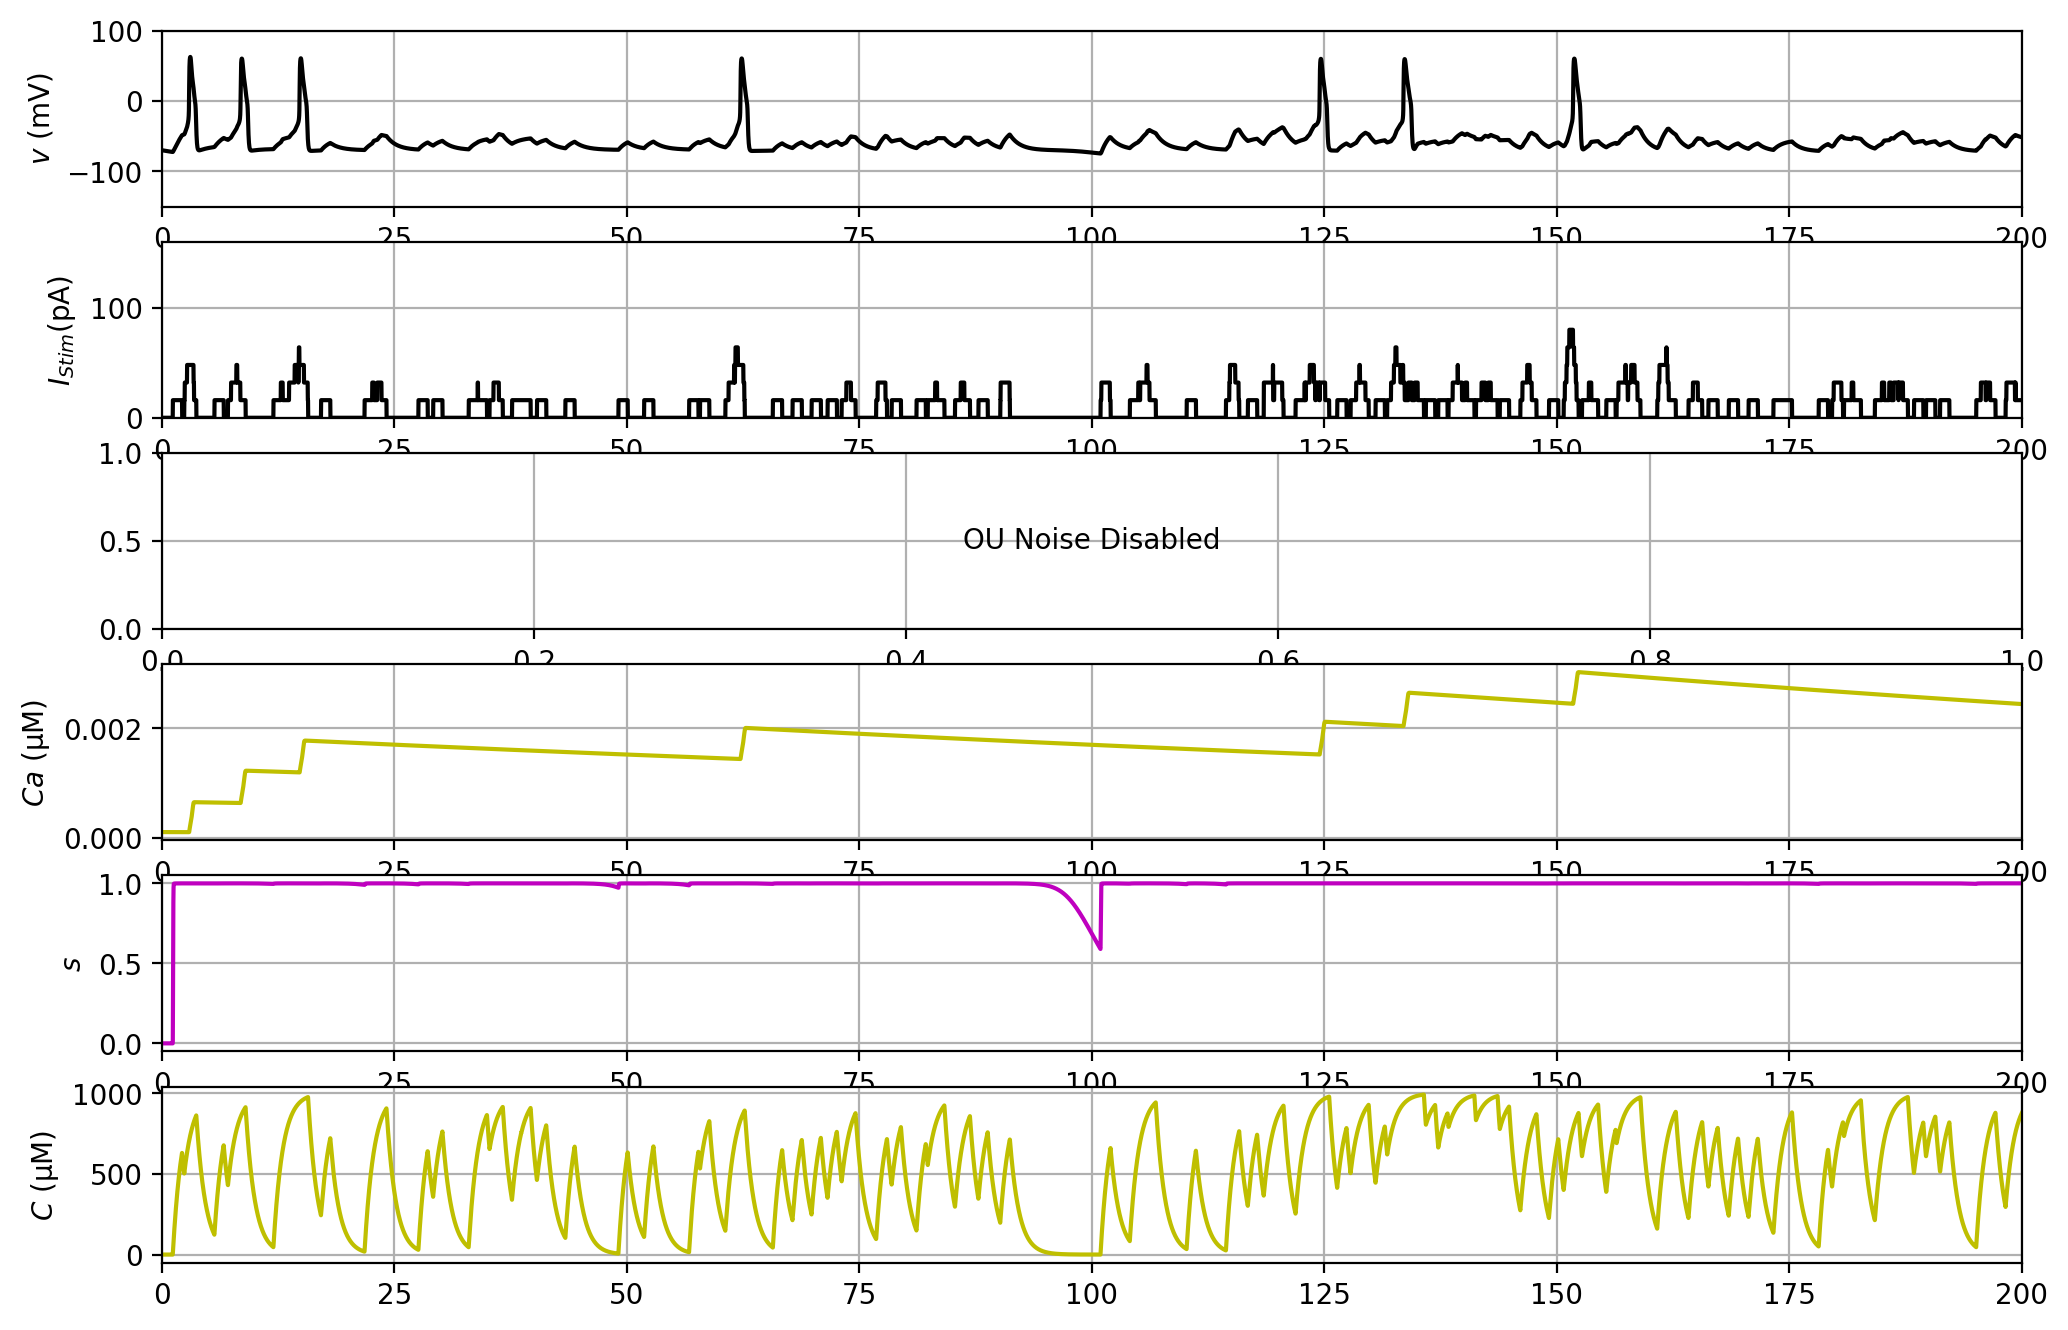

Número de espigas: 7
Frecuencia (Hz): 35.00175008750438


In [4]:
%run "Núcleo.ipynb" # Corremos el núcleo para aprovechar las simulaciones del otro código

In [5]:
p_young = copy.deepcopy(p) # Hacemos copia de nuestro diccionario principal en dos nuevos diccionarios
p_old   = copy.deepcopy(p) # Uno destinado a la célula joven (p_young) y otro a la vieja (p_old)

Semilla = random.randint(1, 10000) # Fijamos una semilla de nuestro tren sináptico para asegurarnos de que
                                   # ambas células reciban la misma estimulación

# Colocamos los parámetros que nos permiten indagar en la electrofisiología de cada célula 

p_young['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_young['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_young['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_young['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_young['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_young['gSyn']= 0.2 # conductancia sináptica
p_young['gK']= 200.0 # Conductancia del potasio K+
p_young['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_young['gNa']= 30.0 # Conductancia del sodio Na+
p_young['gCa']= 1.0 # Conductancia del calcio 
p_young['gL']= 0.01 # Conductancia de fuga 
p_young['useOU'] = False # Booleana para activar/desactivar el ruido OU
p_young['usePulseTrain'] = True # Activar tren de pulsos
p_young['pulseAmp'] = 13.5 # Amplitud del pulso  
p_young['pulseRate'] = 0.75 # λ del Poisson 

p_old['EK'] = -90.0 # Potencial de Nernst para el potasio K+
p_old['ENa']= 60.0 # Potencial de Nernst para el sodio Na+
p_old['ECa']= 120.0 # Potencial de Nernst para el calcio Ca+2
p_old['EL']= -65.0 # Potencial de Nernst para la corriente de fuga
p_old['ESyn']= 0.0 # potencial sináptico (0 para excitatoria)
p_old['gSyn']= 0.2 # conductancia sináptica
p_old['gK']= 200.0 # Conductancia del potasio K+
p_old['gK(Ca)']= 0.8 # Conductancia del potasio dependiente de calcio 
p_old['gNa']= 30.0 # Conductancia del sodio Na+
p_old['gCa']= 2.0 # Conductancia del calcio 
p_old['gL']= 0.01 # Conductancia de fuga
p_old['useOU'] = False # Booleana para activar/desactivar el ruido OU
p_old['usePulseTrain'] = True # Activar tren de pulsos
p_old['pulseAmp'] = 13.5 # Amplitud del pulso  
p_old['pulseRate'] = 0.75 # λ del Poisson 

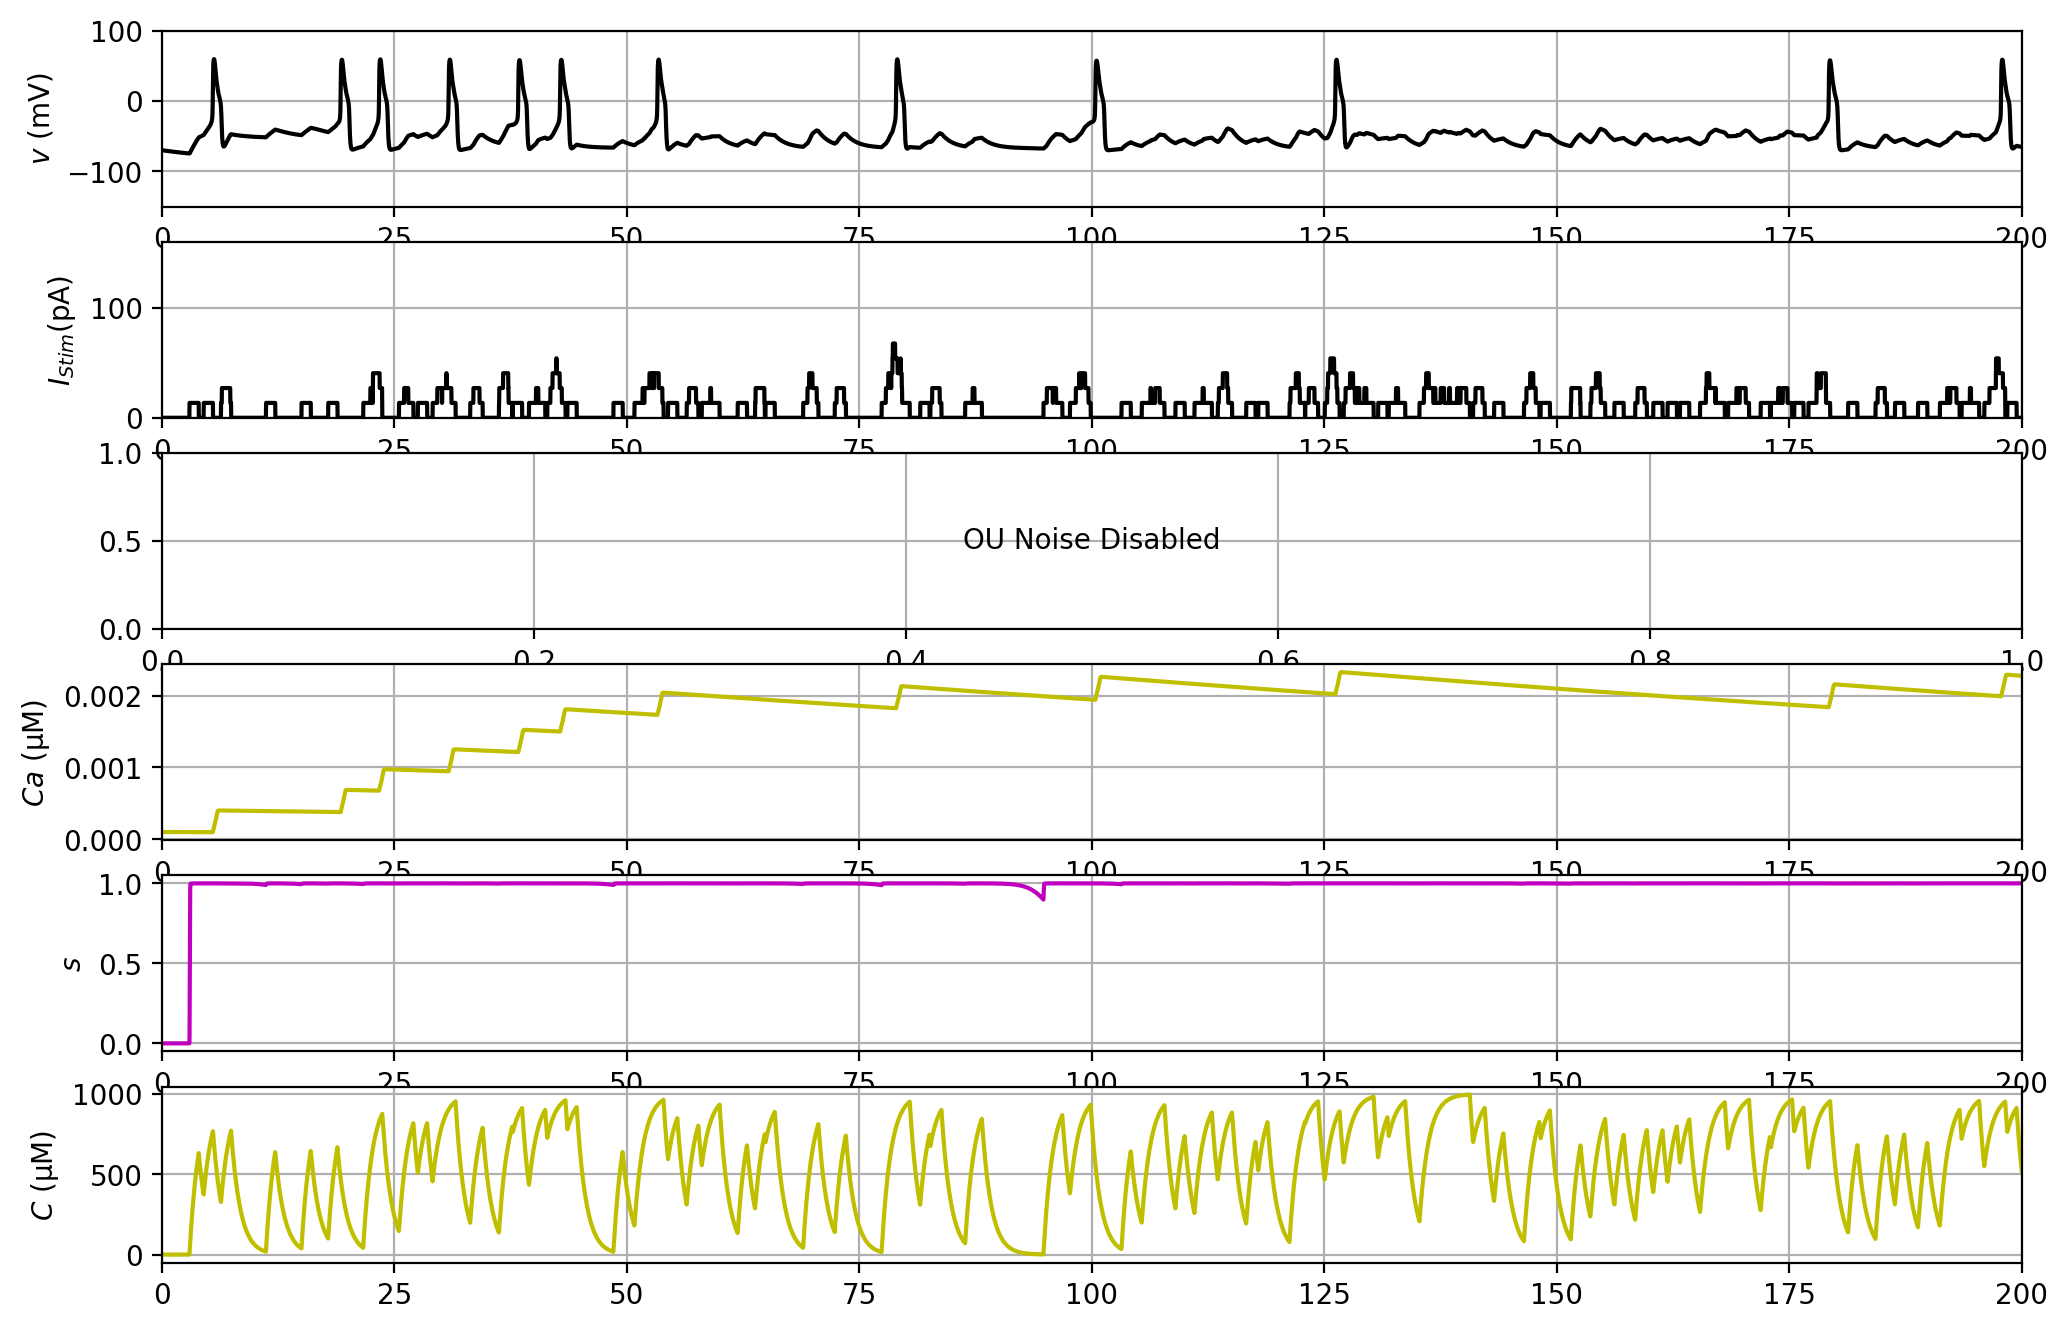

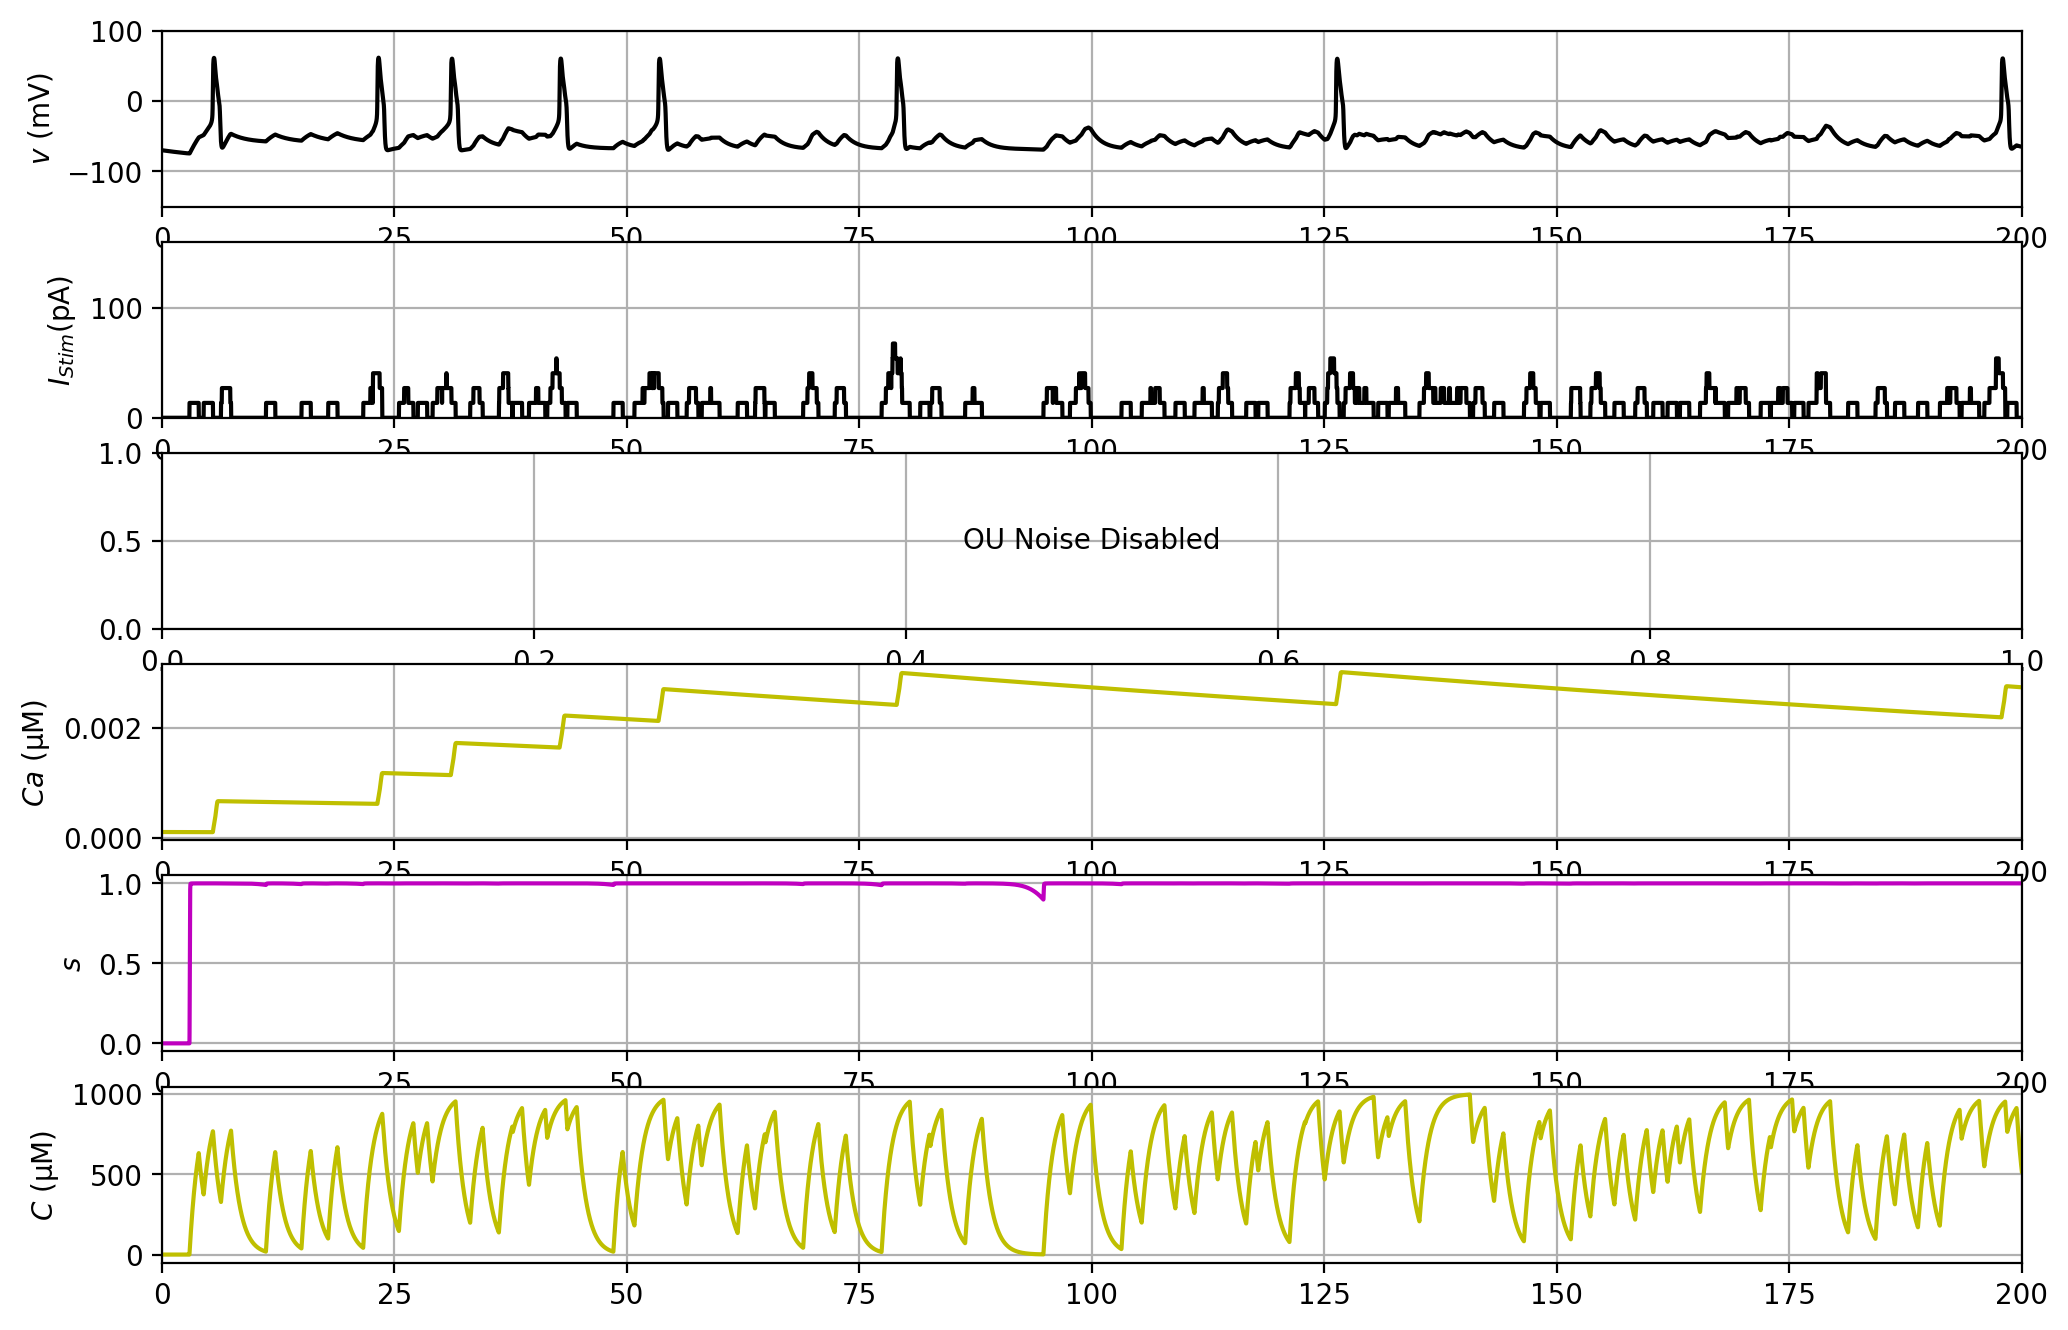

Número de espigas de la célula joven: 12
Frecuencia (Hz) de la célula joven: 60.0030001500075
Número de espigas de la célula vieja: 8
Frecuencia (Hz) de la célula vieja: 40.002000100005


In [6]:
xx_young = simulateHH_numba(p_young, seed=Semilla) # Corremos ambas simulaciones 
xx_old   = simulateHH_numba(p_old, seed=Semilla)

n_young, f_young, tiempos_young = contar_espigas(xx_young['sampTimes'], xx_young['v'])
n_old, f_old, tiempos_old = contar_espigas(xx_old['sampTimes'], xx_old['v'])

# Obtener índices de espigas
indices_espiga_young = np.searchsorted(xx_young['sampTimes'], tiempos_young)
indices_espiga_old = np.searchsorted(xx_old['sampTimes'], tiempos_old)

# Voltajes en esos puntos
v_espigas_young = xx_young['v'][indices_espiga_young]
v_espigas_old = xx_old['v'][indices_espiga_old]

print("Número de espigas de la célula joven:", n_young)
print("Frecuencia (Hz) de la célula joven:", f_young)

print("Número de espigas de la célula vieja:", n_old)
print("Frecuencia (Hz) de la célula vieja:", f_old)

In [7]:
n, f, tiempos = contar_espigas(
    xx['sampTimes'],
    xx['v']
)

isi = calcular_ISI(tiempos)

print("Tiempos de las espigas:")
print(tiempos)

print("\nIntervalos entre espigas:")
print(isi)

Tiempos de las espigas:
[2.95, 8.49, 14.83, 62.24, 124.52, 133.53, 151.77]

Intervalos entre espigas:
[ 5.54  6.34 47.41 62.28  9.01 18.24]


In [8]:
n_young, f_young, tiempos_young = contar_espigas(
    xx_young['sampTimes'],
    xx_young['v']
)

n_old, f_old, tiempos_old = contar_espigas(
    xx_old['sampTimes'],
    xx_old['v']
)

isi_young = calcular_ISI(tiempos_young)
isi_old = calcular_ISI(tiempos_old)

print("ISI joven:")
print(isi_young)

print("\nISI vieja:")
print(isi_old)

ISI joven:
[13.75  4.13  7.48  7.49  4.49 10.47 25.66 21.43 25.8  53.06 18.53]

ISI vieja:
[17.7   7.89 11.7  10.63 25.61 47.25 71.55]


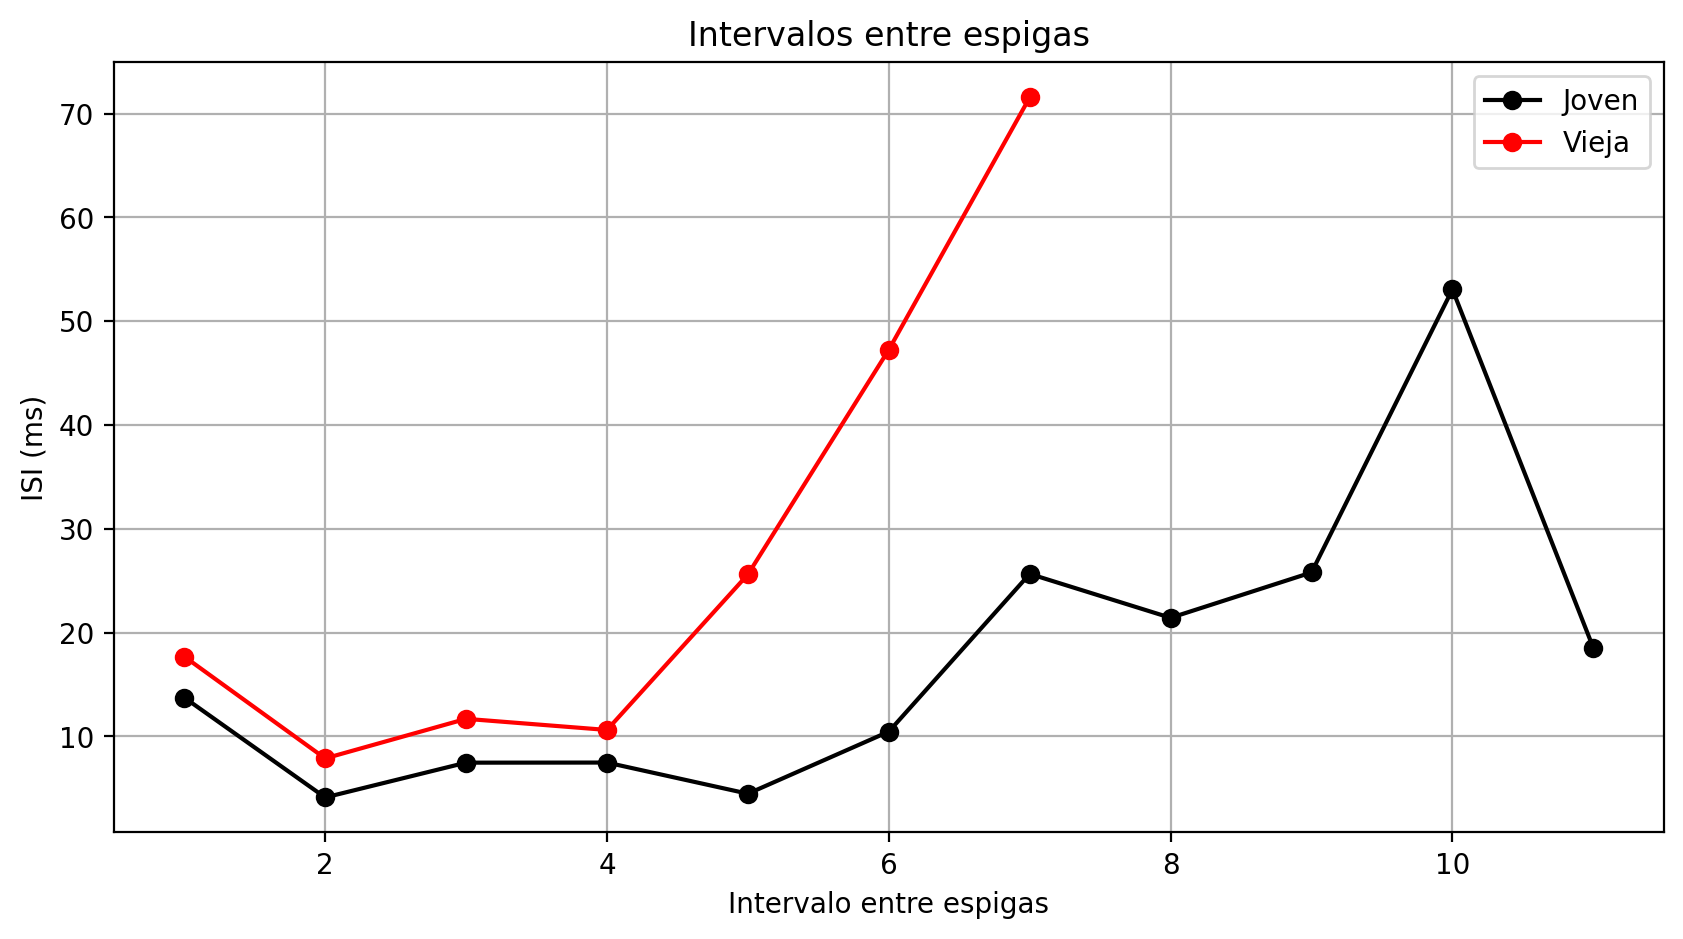

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    np.arange(1, len(isi_young) + 1),
    isi_young,
    'ko-',
    label='Joven'
)

plt.plot(
    np.arange(1, len(isi_old) + 1),
    isi_old,
    'ro-',
    label='Vieja'
)

plt.xlabel('Intervalo entre espigas')
plt.ylabel('ISI (ms)')
plt.title('Intervalos entre espigas')
plt.legend()
plt.grid()

plt.show()